# 🩺 Skin Disease Prediction
### Dataset: [pacificrm/skindiseasedataset](https://www.kaggle.com/datasets/pacificrm/skindiseasedataset)

> **Storage-efficient**: Uses Kaggle API + symlink-based splits — no duplicate image copies on disk.
> **Class filtering**: Unwanted/noisy classes are excluded before any data preparation.

## Step 1 — Install & Import Packages

In [ ]:
!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn

import os, zipfile, shutil, warnings, random, json, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print('✅ Packages ready')

✅ Packages ready


## Step 2 — Upload Kaggle API Key

**How to get `kaggle.json`:**
1. Go to → https://www.kaggle.com/settings
2. Scroll to **API** section → **Create New Token**
3. A `kaggle.json` file downloads — upload it in the cell below

In [ ]:
from google.colab import files

print('📂 Upload your kaggle.json:')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ kaggle.json configured!')

📂 Upload your kaggle.json:


Saving kaggle.json to kaggle.json
✅ kaggle.json configured!


## Step 3 — Download & Extract Dataset

In [ ]:
DATASET  = 'pacificrm/skindiseasedataset'
DATA_DIR = '/content/skin_data'
os.makedirs(DATA_DIR, exist_ok=True)

print(f'⬇️  Downloading {DATASET} ...')
result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', DATASET, '-p', DATA_DIR],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    raise RuntimeError(f'Kaggle download failed:\n{result.stderr}')

# Extract zip then delete it immediately to free space
for zf in [f for f in os.listdir(DATA_DIR) if f.endswith('.zip')]:
    zip_path = os.path.join(DATA_DIR, zf)
    print(f'📦 Extracting {zf} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print('✅ Extracted & zip deleted (storage freed)')

print('\n📁 Top-level contents after extraction:')
for item in sorted(os.listdir(DATA_DIR)):
    print(f'   {item}')

⬇️  Downloading pacificrm/skindiseasedataset ...
Dataset URL: https://www.kaggle.com/datasets/pacificrm/skindiseasedataset
License(s): CC0-1.0


📦 Extracting skindiseasedataset.zip ...
✅ Extracted & zip deleted (storage freed)

📁 Top-level contents after extraction:
   Readme.md
   SkinDisease


## Step 4 — Define Excluded Classes & Locate Dataset Root

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EXCLUDED CLASSES
# Add / remove entries here at any time.
# Matching is case-insensitive and ignores surrounding whitespace.
# ─────────────────────────────────────────────────────────────────────────────
EXCLUDED_CLASSES_RAW = [
    'candidiasis',
    'drug eruption',
    'drug_eruption',
    'drugeruption',
    'Unknown_Normal ',   # note: trailing space handled automatically
    'Eczema ',           # note: trailing space handled automatically
    'Benign_tumors',
]

# Normalise once — strip whitespace & lowercase for reliable comparison
EXCLUDED_CLASSES = set(c.strip().lower() for c in EXCLUDED_CLASSES_RAW)
print(f'🚫 Normalised exclusion set ({len(EXCLUDED_CLASSES)}):')
for c in sorted(EXCLUDED_CLASSES):
    print(f'   "{c}"')


# ─────────────────────────────────────────────────────────────────────────────
# Auto-detect the directory whose immediate sub-folders are image classes
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def folder_has_images(path):
    try:
        return any(
            Path(f).suffix.lower() in IMAGE_EXTS
            for f in os.listdir(path)
            if os.path.isfile(os.path.join(path, f))
        )
    except PermissionError:
        return False

def find_dataset_root(base):
    """Walk base directory and return the first dir
    whose sub-folders contain images (= class-folder structure).
    """
    for root, dirs, _ in os.walk(base):
        class_dirs = [d for d in dirs
                      if folder_has_images(os.path.join(root, d))]
        if len(class_dirs) >= 2:
            return root, class_dirs
    return None, []

DATASET_ROOT, raw_classes = find_dataset_root(DATA_DIR)
if DATASET_ROOT is None:
    raise FileNotFoundError(
        '❌ Could not find class-folder image structure under DATA_DIR.'
        '\nCheck the extracted folder layout above.'
    )

print(f'\n📂 Dataset root: {DATASET_ROOT}')
print(f'   Raw folders found: {sorted(raw_classes)}')

🚫 Normalised exclusion set (7):
   "benign_tumors"
   "candidiasis"
   "drug eruption"
   "drug_eruption"
   "drugeruption"
   "eczema"
   "unknown_normal"

📂 Dataset root: /content/skin_data/SkinDisease/SkinDisease/test
   Raw folders found: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


## Step 5 — Filter Classes & Print Summary

In [ ]:
# Apply exclusion filter (normalised comparison)
included_classes = sorted([
    c for c in raw_classes
    if c.strip().lower() not in EXCLUDED_CLASSES
])
skipped_classes = sorted([
    c for c in raw_classes
    if c.strip().lower() in EXCLUDED_CLASSES
])

print(f'✅ INCLUDED classes ({len(included_classes)}):')
for c in included_classes:
    n = len([
        f for f in os.listdir(os.path.join(DATASET_ROOT, c))
        if Path(f).suffix.lower() in IMAGE_EXTS
    ])
    print(f'   {c:<40} {n:>5} images')

print(f'\n🚫 EXCLUDED classes ({len(skipped_classes)}):')
for c in skipped_classes:
    n = len([
        f for f in os.listdir(os.path.join(DATASET_ROOT, c))
        if Path(f).suffix.lower() in IMAGE_EXTS
    ])
    print(f'   {c:<40} {n:>5} images  ← will be ignored')

NUM_CLASSES = len(included_classes)
CLASS_NAMES = included_classes

total = sum(
    len([f for f in os.listdir(os.path.join(DATASET_ROOT, c))
         if Path(f).suffix.lower() in IMAGE_EXTS])
    for c in CLASS_NAMES
)
print(f'\n🖼️  Total usable images: {total}')
print(f'   NUM_CLASSES          : {NUM_CLASSES}')

✅ INCLUDED classes (17):
   Acne                                        65 images
   Actinic_Keratosis                           83 images
   Bullous                                     55 images
   Infestations_Bites                          60 images
   Lichen                                      61 images
   Lupus                                       34 images
   Moles                                       40 images
   Psoriasis                                   88 images
   Rosacea                                     28 images
   Seborrh_Keratoses                           51 images
   SkinCancer                                  77 images
   Sun_Sunlight_Damage                         34 images
   Tinea                                      102 images
   Vascular_Tumors                             60 images
   Vasculitis                                  52 images
   Vitiligo                                    82 images
   Warts                                       64 images

🚫 EXC

## Step 6 — Symlink-Based Train / Val / Test Split (Zero Extra Disk Space)

In [ ]:
SPLIT_DIR  = '/content/skin_split'
TRAIN_DIR  = os.path.join(SPLIT_DIR, 'train')
VAL_DIR    = os.path.join(SPLIT_DIR, 'val')
TEST_DIR   = os.path.join(SPLIT_DIR, 'test')

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

# Remove stale split if re-running this cell
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for cls in CLASS_NAMES:   # <-- only INCLUDED classes
    src_dir = os.path.join(DATASET_ROOT, cls)
    images  = [
        f for f in os.listdir(src_dir)
        if Path(f).suffix.lower() in IMAGE_EXTS
    ]

    train_imgs, temp_imgs = train_test_split(
        images, test_size=1 - TRAIN_RATIO, random_state=RANDOM_SEED
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        random_state=RANDOM_SEED
    )

    for split_name, split_imgs in [('train', train_imgs),
                                    ('val',   val_imgs),
                                    ('test',  test_imgs)]:
        dest = os.path.join(SPLIT_DIR, split_name, cls)
        os.makedirs(dest, exist_ok=True)
        for img in split_imgs:
            src  = os.path.join(src_dir, img)
            link = os.path.join(dest, img)
            if not os.path.exists(link):
                os.symlink(src, link)   # symlink = zero extra storage

train_count = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES)
val_count   = sum(len(os.listdir(os.path.join(VAL_DIR,   c))) for c in CLASS_NAMES)
test_count  = sum(len(os.listdir(os.path.join(TEST_DIR,  c))) for c in CLASS_NAMES)

print('✅ Split ready (symlinks — no extra disk usage):')
print(f'   Train : {train_count}')
print(f'   Val   : {val_count}')
print(f'   Test  : {test_count}')
print(f'\n   Excluded classes are completely absent from all splits.')

✅ Split ready (symlinks — no extra disk usage):
   Train : 714
   Val   : 155
   Test  : 167

   Excluded classes are completely absent from all splits.


## Step 7 — Visualise Class Distribution (Included Only)

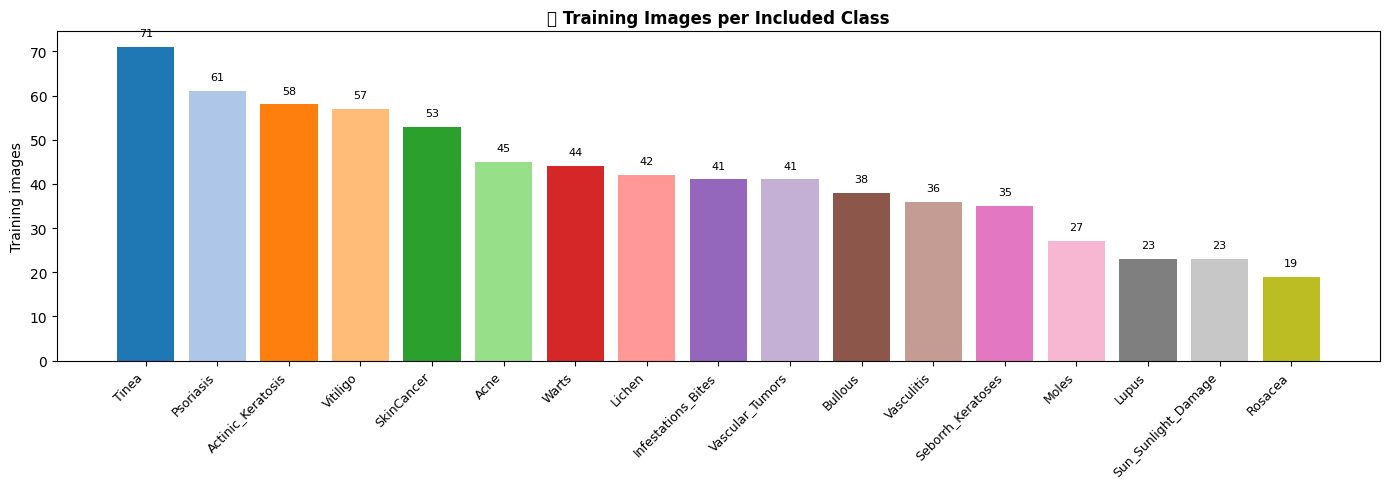


🚫 Excluded classes (not shown above, not in training):
   Benign_tumors                            121 images ignored
   Candidiasis                              27 images ignored
   DrugEruption                             61 images ignored
   Eczema                                   112 images ignored
   Unknown_Normal                           189 images ignored


In [ ]:
class_counts = {
    cls: len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    for cls in CLASS_NAMES
}
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 5))
colors = plt.cm.tab20.colors
bars = plt.bar(sorted_counts.keys(), sorted_counts.values(),
               color=[colors[i % 20] for i in range(len(sorted_counts))])
for bar, v in zip(bars, sorted_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(v), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Training images')
plt.title('📊 Training Images per Included Class', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🚫 Excluded classes (not shown above, not in training):')
for c in skipped_classes:
    n_orig = len([f for f in os.listdir(os.path.join(DATASET_ROOT, c))
                  if Path(f).suffix.lower() in IMAGE_EXTS])
    print(f'   {c:<40} {n_orig} images ignored')

## Step 8 — Sample Images Preview

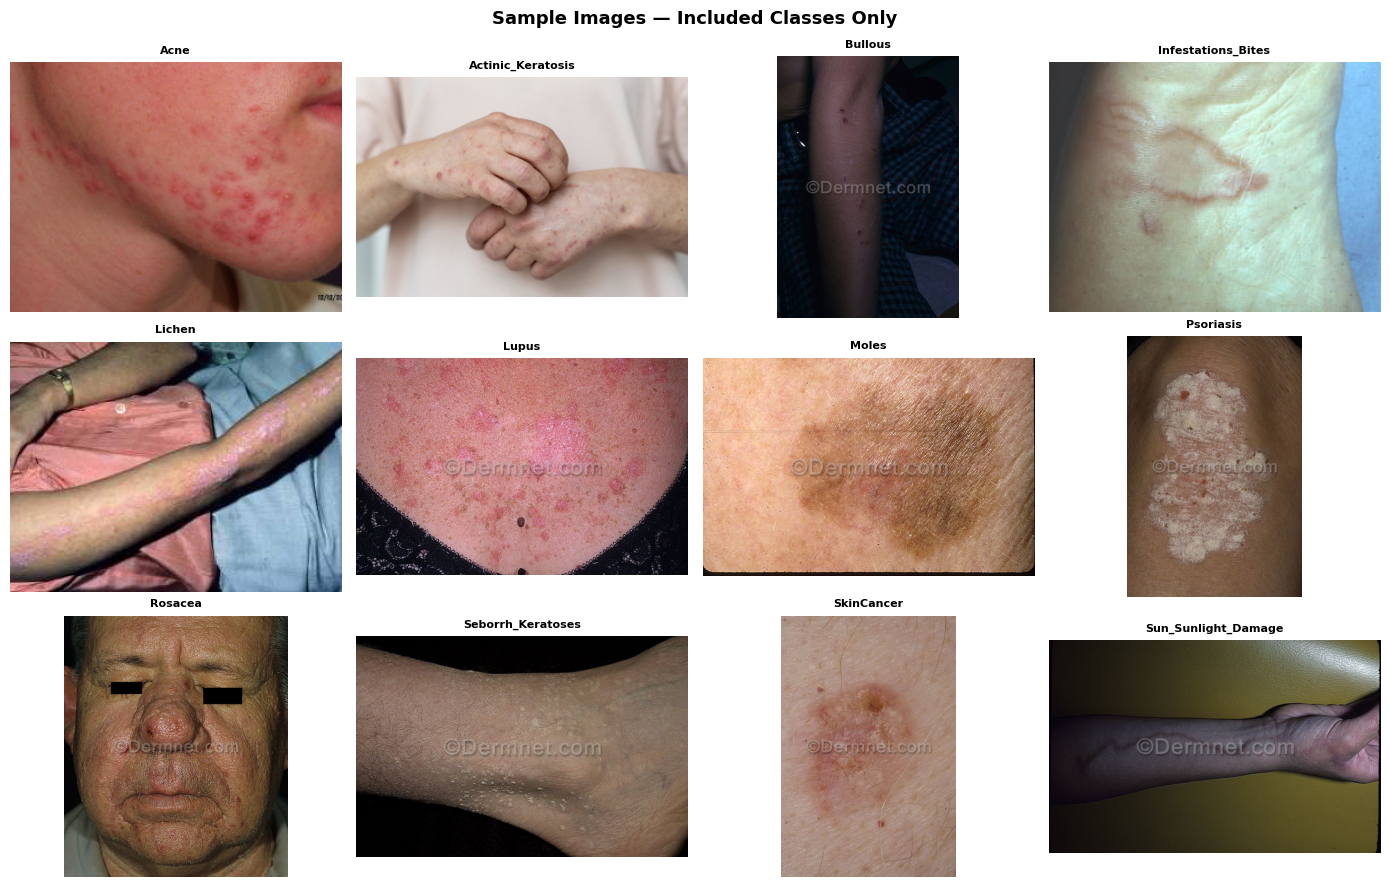

In [ ]:
n_show = min(NUM_CLASSES, 12)
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES[:n_show]):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_dir) if Path(f).suffix.lower() in IMAGE_EXTS]
    if imgs:
        img_path = os.path.join(cls_dir, random.choice(imgs))
        axes[i].imshow(mpimg.imread(img_path))
    axes[i].set_title(cls, fontsize=8, fontweight='bold')
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images — Included Classes Only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9 — Data Generators

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

eval_gen = ImageDataGenerator(rescale=1./255)

# classes= pins the label order to CLASS_NAMES
# — excluded classes are never referenced here
train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    shuffle=True, seed=RANDOM_SEED
)
val_data = eval_gen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False
)
test_data = eval_gen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False
)

print(f'✅ Generators ready')
print(f'   Classes  : {list(train_data.class_indices.keys())}')
print(f'   Excluded : {skipped_classes}')

Found 714 images belonging to 17 classes.
Found 155 images belonging to 17 classes.
Found 167 images belonging to 17 classes.
✅ Generators ready
   Classes  : ['Acne', 'Actinic_Keratosis', 'Bullous', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
   Excluded : ['Benign_tumors', 'Candidiasis', 'DrugEruption', 'Eczema', 'Unknown_Normal']


## Step 10 — Build Model (EfficientNetB0 Transfer Learning)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_model = EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False   # Freeze for Phase 1

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)   # NUM_CLASSES = included only

model = models.Model(inputs, outputs)
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\n✅ Output layer: {NUM_CLASSES} neurons → {CLASS_NAMES}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,846,260 (18.49 MB)

 Trainable params: 794,129 (3.03 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


✅ Output layer: 17 neurons → ['Acne', 'Actinic_Keratosis', 'Bullous', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


## Step 11 — Phase 1: Train Classification Head

In [ ]:
CHECKPOINT = '/content/best_skin_model.keras'

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(CHECKPOINT, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('🚀 Phase 1 — Training head with frozen EfficientNetB0 base...')
history1 = model.fit(
    train_data, epochs=15, validation_data=val_data,
    callbacks=cb1, verbose=1
)
print('✅ Phase 1 complete')

🚀 Phase 1 — Training head with frozen EfficientNetB0 base...
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0754 - loss: 3.2851
Epoch 1: val_accuracy improved from None to 0.09677, saving model to /content/best_skin_model.keras

Epoch 1: finished saving model to /content/best_skin_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.0686 - loss: 3.3453 - val_accuracy: 0.0968 - val_loss: 2.8280 - learning_rate: 0.0010
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.0533 - loss: 3.3278
Epoch 2: val_accuracy did not improve from 0.09677
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 504ms/step - accuracy: 0.0616 - loss: 3.2340 - val_accuracy: 0.0774 - val_loss: 2.8114 - learning_rate: 0.0010
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.0862 - loss: 3.1116
Epoch 3: val_accuracy did not improve from 0.09677
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 467ms/step - accuracy: 0.0854 - loss: 3.1119 - val_accuracy: 0.0968 - val_loss: 2.8174 - learning_rate: 

## Step 12 — Phase 2: Fine-Tune Top Layers

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:   # Keep bottom layers frozen
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),   # Much lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(CHECKPOINT, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('🔧 Phase 2 — Fine-tuning top 30 layers...')
history2 = model.fit(
    train_data, epochs=20, validation_data=val_data,
    callbacks=cb2, verbose=1
)
print('✅ Phase 2 complete')

🔧 Phase 2 — Fine-tuning top 30 layers...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0616 - loss: 3.5323
Epoch 1: val_accuracy improved from None to 0.09677, saving model to /content/best_skin_model.keras

Epoch 1: finished saving model to /content/best_skin_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.0672 - loss: 3.4481 - val_accuracy: 0.0968 - val_loss: 2.8351 - learning_rate: 1.0000e-05
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.0764 - loss: 3.3127
Epoch 2: val_accuracy did not improve from 0.09677
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 502ms/step - accuracy: 0.0714 - loss: 3.2834 - val_accuracy: 0.0968 - val_loss: 2.8451 - learning_rate: 1.0000e-05
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.0790 - loss: 3.1336
Epoch 3: val_accuracy did not improve from 0.09677
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 470ms/step - accuracy: 0.0770 - loss: 3.1847 - val_accuracy: 0.0968 - val_loss: 2.8573 - learning_rate: 1.0000e-05
E

## Step 13 — Plot Training History

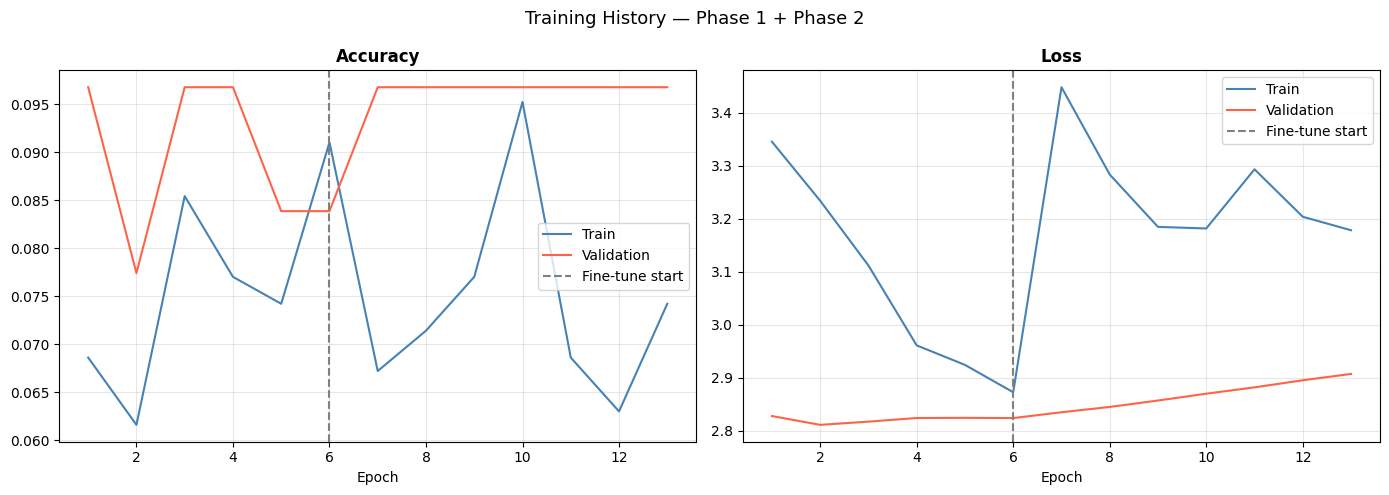

In [ ]:
def merge_histories(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

hist       = merge_histories(history1, history2)
phase1_end = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [(ax1,'accuracy','Accuracy'),(ax2,'loss','Loss')]:
    ep = range(1, len(hist[metric]) + 1)
    ax.plot(ep, hist[metric],           label='Train',      color='steelblue')
    ax.plot(ep, hist[f'val_{metric}'],  label='Validation', color='tomato')
    ax.axvline(phase1_end, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — Phase 1 + Phase 2', fontsize=13)
plt.tight_layout()
plt.show()

## Step 14 — Evaluate on Test Set

In [ ]:
print('🔍 Evaluating on held-out test set ...')
test_data.reset()
y_pred_probs = model.predict(test_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_data.classes

acc = accuracy_score(y_true, y_pred)
print(f'\n✅ Test Accuracy: {acc*100:.2f}%')
print('\n📋 Classification Report (included classes only):')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

🔍 Evaluating on held-out test set ...
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

✅ Test Accuracy: 9.58%

📋 Classification Report (included classes only):
                     precision    recall  f1-score   support

               Acne       0.00      0.00      0.00        10
  Actinic_Keratosis       0.00      0.00      0.00        13
            Bullous       0.00      0.00      0.00         9
 Infestations_Bites       0.00      0.00      0.00        10
             Lichen       0.00      0.00      0.00        10
              Lupus       0.00      0.00      0.00         6
              Moles       0.00      0.00      0.00         7
          Psoriasis       0.00      0.00      0.00        14
            Rosacea       0.00      0.00      0.00         5
  Seborrh_Keratoses       0.00      0.00      0.00         8
         SkinCancer       0.00      0.00      0.00        12
Sun_Sunlight_Damage       0.00      0.00      0.00         6
              Tinea       0.10      1.00      0.17       

## Step 15 — Confusion Matrix

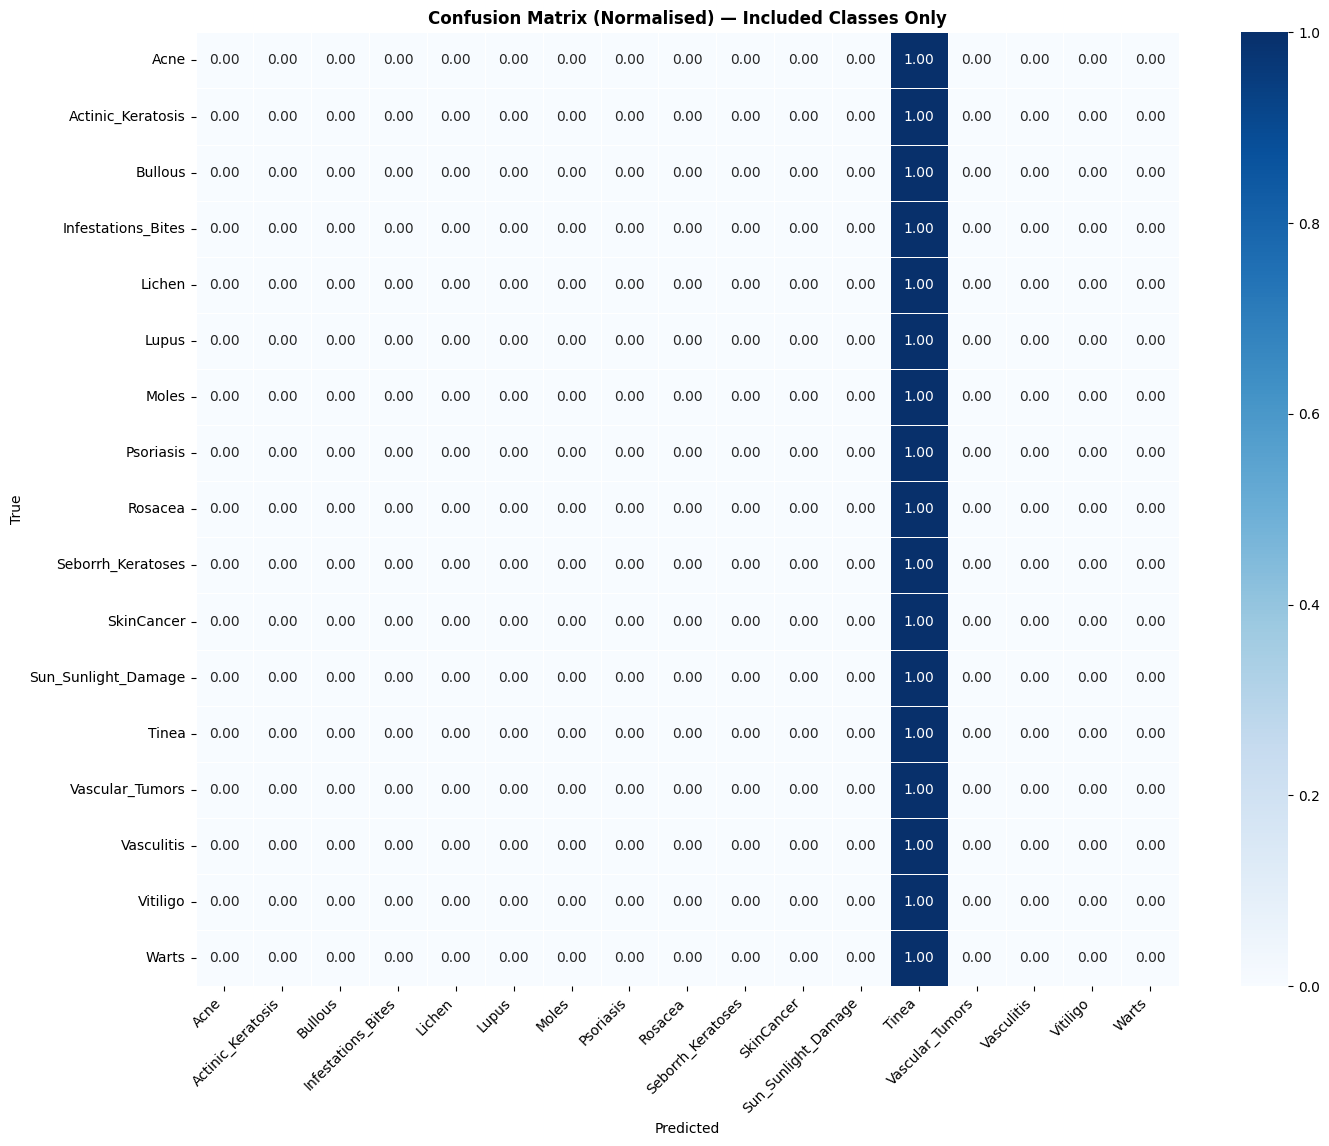

In [ ]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_sz = max(10, NUM_CLASSES * 0.85)
plt.figure(figsize=(fig_sz, fig_sz * 0.8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix (Normalised) — Included Classes Only',
          fontweight='bold', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 16 — Predict a Single Image


🩺 Prediction: atypical-nevi-dermoscopy-62.jpeg
   #1: Tinea                                    11.40%
   #2: Vascular_Tumors                          9.98%
   #3: Psoriasis                                6.94%


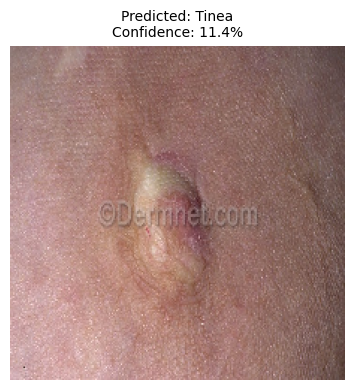

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, top_k=3):
    """Predict skin disease. Returns only included-class predictions."""
    img  = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, 0)
    preds = model.predict(arr, verbose=0)[0]

    top_indices = preds.argsort()[::-1][:top_k]
    print(f'\n🩺 Prediction: {os.path.basename(img_path)}')
    for rank, idx in enumerate(top_indices, 1):
        print(f'   #{rank}: {CLASS_NAMES[idx]:<40} {preds[idx]*100:.2f}%')

    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    plt.title(
        f'Predicted: {CLASS_NAMES[top_indices[0]]}\n'
        f'Confidence: {preds[top_indices[0]]*100:.1f}%',
        fontsize=10
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Demo: random test image
sample_cls  = random.choice(CLASS_NAMES)
sample_dir  = os.path.join(TEST_DIR, sample_cls)
sample_imgs = [f for f in os.listdir(sample_dir) if Path(f).suffix.lower() in IMAGE_EXTS]
if sample_imgs:
    predict_image(os.path.join(sample_dir, random.choice(sample_imgs)))

## Step 17 — Upload & Predict Your Own Image

📤 Upload a skin image:


Saving img.jpg to img.jpg

🩺 Prediction: img.jpg
   #1: Tinea                                    11.38%
   #2: Vascular_Tumors                          9.99%
   #3: Psoriasis                                6.93%


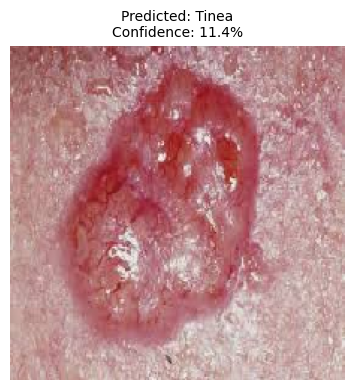

In [ ]:
from google.colab import files as colab_files

print('📤 Upload a skin image:')
uploaded_img = colab_files.upload()

for fname, data in uploaded_img.items():
    save_path = f'/content/{fname}'
    with open(save_path, 'wb') as f:
        f.write(data)
    predict_image(save_path)

## Step 18 — Save Model & Class Names

In [ ]:
FINAL_MODEL   = '/content/skin_disease_model.keras'
CLASS_JSON    = '/content/class_names.json'

model.save(FINAL_MODEL)
with open(CLASS_JSON, 'w') as f:
    json.dump({
        'included_classes': CLASS_NAMES,
        'excluded_classes': sorted(skipped_classes),
        'num_classes'      : NUM_CLASSES
    }, f, indent=2)

print(f'✅ Model saved  : {FINAL_MODEL}')
print(f'✅ Classes saved: {CLASS_JSON}')
print(f'   Included ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'   Excluded ({len(skipped_classes)}): {sorted(skipped_classes)}')

from google.colab import files as colab_files
colab_files.download(FINAL_MODEL)
colab_files.download(CLASS_JSON)
print('\n⬇️  Downloads triggered!')

✅ Model saved  : /content/skin_disease_model.keras
✅ Classes saved: /content/class_names.json
   Included (17): ['Acne', 'Actinic_Keratosis', 'Bullous', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
   Excluded (5): ['Benign_tumors', 'Candidiasis', 'DrugEruption', 'Eczema', 'Unknown_Normal']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Downloads triggered!
